In [27]:
import pandas as pd
df = pd.read_csv("mental_health_data final data.csv")
print(df.shape)
print(df.columns)

(50000, 17)
Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Country',
       'Mental_Health_Condition', 'Severity', 'Consultation_History',
       'Stress_Level', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours',
       'Social_Media_Usage', 'Diet_Quality', 'Smoking_Habit',
       'Alcohol_Consumption', 'Medication_Usage'],
      dtype='object')


In [28]:
df.dtypes

User_ID                      int64
Age                          int64
Gender                      object
Occupation                  object
Country                     object
Mental_Health_Condition     object
Severity                    object
Consultation_History        object
Stress_Level                object
Sleep_Hours                float64
Work_Hours                   int64
Physical_Activity_Hours      int64
Social_Media_Usage         float64
Diet_Quality                object
Smoking_Habit               object
Alcohol_Consumption         object
Medication_Usage            object
dtype: object

In [29]:
df.isnull().sum()

User_ID                        0
Age                            0
Gender                         0
Occupation                     0
Country                        0
Mental_Health_Condition        0
Severity                   25002
Consultation_History           0
Stress_Level                   0
Sleep_Hours                    0
Work_Hours                     0
Physical_Activity_Hours        0
Social_Media_Usage             0
Diet_Quality                   0
Smoking_Habit                  0
Alcohol_Consumption            0
Medication_Usage               0
dtype: int64

In [30]:
#Define target and features
y = df['Stress_Level']  # Target variable
X = df[['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours',
        'Diet_Quality', 'Social_Media_Usage', 'Smoking_Habit', 'Alcohol_Consumption']]

In [31]:
#Using copy to avoid warnings and ensuring working with a clean independent object.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Using copy to avoid warnings and ensuring working with a clean independent object.
X = X.copy()
X[['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']] = scaler.fit_transform(
    X[['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']]
)

In [32]:
#ONLY TRAIN SET!!!
#Normalize continuous features #Only train set (This ensures that the test data is scaled using the same parameters (mean and std) learned from the training data.)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Assuming your full feature set is in X and target in y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train[['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage'], index=X_train.index)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test[['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=['Work_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage'], index=X_test.index)


In [33]:
#Split data for modeling

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
#Logistic regression
#Replace unknown with 0
df['Severity'] = df['Severity'].replace('unknown', 0)

df['Severity'] = df['Severity'].replace('unknown', 0).fillna(0)

In [35]:
#Encode as ordinal
severity_map = {'low': 1, 'moderate': 2, 'high': 3, 0: 0}
df['Severity'] = df['Severity'].map(severity_map)


In [36]:
#Define Features and Target
X = df[[
    'Gender', 'Occupation', 'Mental_Health_Condition', 'Severity',
    'Consultation_History', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours',
    'Social_Media_Usage', 'Diet_Quality', 'Smoking_Habit', 'Alcohol_Consumption',
    'Medication_Usage'
]]
y = df['Stress_Level']


In [37]:
#Encode Categorical Features
X_encoded = pd.get_dummies(X, drop_first=True)


In [38]:
import numpy as np
print(X_encoded.isnull().sum())  # See which columns have missing values
print(np.isinf(X_encoded).sum()) # Check for infinite values


Severity                               24998
Sleep_Hours                                0
Work_Hours                                 0
Physical_Activity_Hours                    0
Social_Media_Usage                         0
Gender_Male                                0
Gender_Non-binary                          0
Gender_Prefer not to say                   0
Occupation_Engineering                     0
Occupation_Finance                         0
Occupation_Healthcare                      0
Occupation_IT                              0
Occupation_Other                           0
Occupation_Sales                           0
Mental_Health_Condition_Yes                0
Consultation_History_Yes                   0
Diet_Quality_Healthy                       0
Diet_Quality_Unhealthy                     0
Smoking_Habit_Non-Smoker                   0
Smoking_Habit_Occasional Smoker            0
Smoking_Habit_Regular Smoker               0
Alcohol_Consumption_Non-Drinker            0
Alcohol_Co

In [39]:
X_encoded = X_encoded.fillna(0)



In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)


In [41]:
#Scale numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)



In [42]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [43]:
#Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [44]:
#Evaluate model
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

        High       0.34      0.33      0.33      3406
         Low       0.32      0.32      0.32      3280
      Medium       0.32      0.33      0.33      3314

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.33      0.33      0.33     10000

[[1108 1114 1184]
 [1096 1060 1124]
 [1062 1142 1110]]


In [51]:
# Convert boolean columns to integers
X_train_cat = X_train_cat.astype(int)
X_test_cat = X_test_cat.astype(int)


In [52]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert all boolean columns to integers
X_encoded = X_encoded.astype({col: int for col in X_encoded.columns if X_encoded[col].dtype == 'bool'})


In [53]:
# Impute categorical columns
X_train_cat_imputed = pd.DataFrame(cat_imputer.fit_transform(X_train_cat), columns=X_train_cat.columns, index=X_train.index)
X_test_cat_imputed = pd.DataFrame(cat_imputer.transform(X_test_cat), columns=X_test_cat.columns, index=X_test.index)


In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Drop non-predictive ID column
df_clean = df.drop(columns=['User_ID'])

# Separate target
y = df_clean['Stress_Level']
X = df_clean.drop(columns=['Stress_Level'])

# Identify column types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert boolean columns to integers
X_encoded = X_encoded.astype({col: int for col in X_encoded.columns if X_encoded[col].dtype == 'bool'})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Impute missing values
num_imputer = SimpleImputer(strategy='mean')
X_train[numerical_cols] = num_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = num_imputer.transform(X_test[numerical_cols])

cat_cols = [col for col in X_train.columns if col not in numerical_cols]
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Train logistic regression
logreg = LogisticRegression(max_iter=1000, multi_class='ovr', solver='lbfgs')
logreg.fit(X_train, y_train)

# Predict probabilities
y_proba = logreg.predict_proba(X_test)

# Binarize target labels for AUC
y_test_bin = label_binarize(y_test, classes=['Low', 'Medium', 'High'])

# Compute AUC
auc_score = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro')
print(f"✅ Multiclass AUC (OvR, macro-average): {auc_score:.4f}")


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Multiclass AUC (OvR, macro-average): 0.5092


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)

auc_rf = roc_auc_score(label_binarize(y_test, classes=['Low', 'Medium', 'High']), y_proba_rf, multi_class='ovr', average='macro')
print(f"🌲 Random Forest AUC: {auc_rf:.4f}")


🌲 Random Forest AUC: 0.5039


In [64]:
!pip install lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.3 MB/s eta 0:00:00a 0:00:01


In [65]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [66]:
try:
    from lightgbm import LGBMClassifier
except ModuleNotFoundError:
    print("❌ LightGBM is not installed. Run '!pip install lightgbm' to install it.")


In [67]:
try:
    from xgboost import XGBClassifier
except ModuleNotFoundError:
    print("❌ XGBoost is not installed. Run '!pip install xgboost' to install it.")


In [79]:
# 🎯 Target and features
df_clean = df.drop(columns=['User_ID'])
y = df_clean['Stress_Level']
X = df_clean.drop(columns=['Stress_Level'])

# 🔢 Encode target labels as integers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Converts ['Low', 'Medium', 'High'] → [0, 1, 2]

# 🧠 One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=X.select_dtypes(include='object').columns.tolist(), drop_first=True)

# 📊 Train-test split using encoded labels
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)


In [81]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])


In [82]:

# Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Optional: install xgboost if needed
# !pip install xgboost

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 🎯 Target and features
df_clean = df.drop(columns=['User_ID'])
y = df_clean['Stress_Level']
X = df_clean.drop(columns=['Stress_Level'])

# 🔍 Identify column types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 🧠 One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 🔧 Convert boolean columns to integers
X_encoded = X_encoded.astype({col: int for col in X_encoded.columns if X_encoded[col].dtype == 'bool'})

# 📊 Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 🧼 Impute missing values
num_imputer = SimpleImputer(strategy='mean')
X_train[numerical_cols] = num_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = num_imputer.transform(X_test[numerical_cols])

cat_cols = [col for col in X_train.columns if col not in numerical_cols]
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# 📏 Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 🔁 Binarize target labels for AUC
y_test_bin = label_binarize(y_test, classes=['Low', 'Medium', 'High'])

# ⚡ XGBoost
xgb = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb.fit(X_train, y_train)
y_proba_xgb = xgb.predict_proba(X_test)
auc_xgb = roc_auc_score(y_test_bin, y_proba_xgb, multi_class='ovr', average='macro')
print(f"⚡ XGBoost AUC (OvR, macro-average): {auc_xgb:.4f}")

# 🌿 LightGBM
lgbm = LGBMClassifier(objective='multiclass', num_class=3, random_state=42)
lgbm.fit(X_train, y_train)
y_proba_lgbm = lgbm.predict_proba(X_test)
auc_lgbm = roc_auc_score(y_test_bin, y_proba_lgbm, multi_class='ovr', average='macro')
print(f"🌿 LightGBM AUC (OvR, macro-average): {auc_lgbm:.4f}")

# 📊 Feature Importance Plot (LightGBM)
importances = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[:20], y=importances.index[:20], palette='viridis')
plt.title("Top 20 Feature Importances (LightGBM)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['High' 'Low' 'Medium']

In [59]:
from lightgbm import LGBMClassifier

# Train LightGBM model
lgbm = LGBMClassifier(objective='multiclass', num_class=3, random_state=42)
lgbm.fit(X_train, y_train)

# Predict probabilities
y_proba_lgbm = lgbm.predict_proba(X_test)

# Compute AUC
auc_lgbm = roc_auc_score(y_test_bin, y_proba_lgbm, multi_class='ovr', average='macro')
print(f"🌿 LightGBM AUC (OvR, macro-average): {auc_lgbm:.4f}")


ModuleNotFoundError: No module named 'lightgbm'

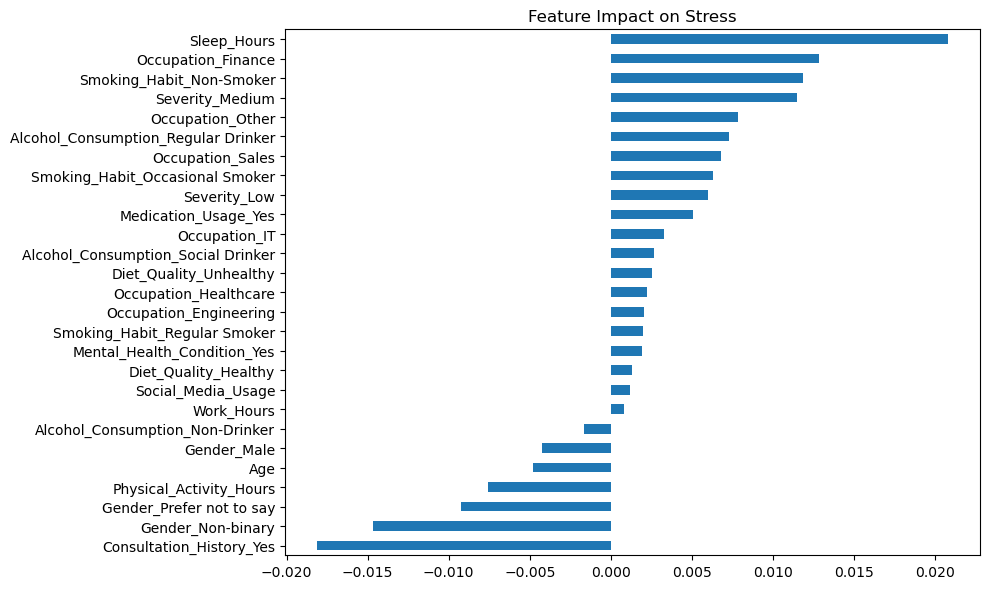

In [ ]:
#Interpret Feature impact
import pandas as pd
import matplotlib.pyplot as plt

coefficients = pd.Series(model.coef_[0], index=X_encoded.columns)
coefficients.sort_values().plot(kind='barh', figsize=(10, 6), title='Feature Impact on Stress')
plt.tight_layout()
plt.show()
